<a href="https://colab.research.google.com/github/hampanass/FML_Labs/blob/main/Lab7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proline  target  
0          

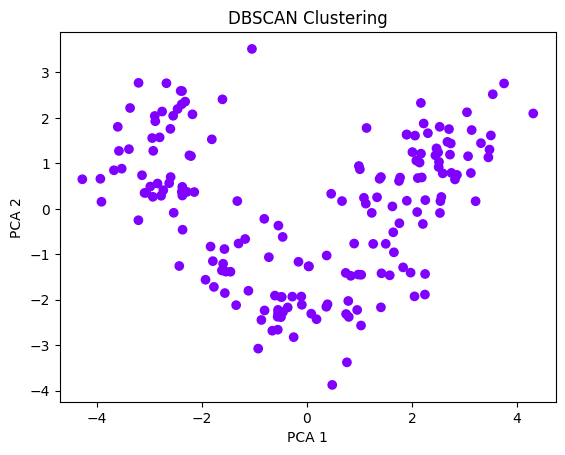

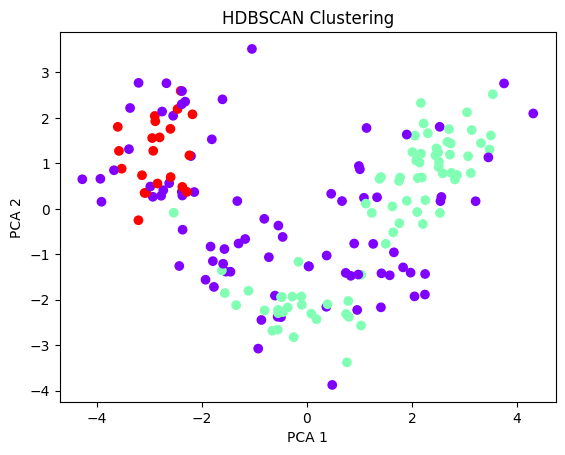


===== DBSCAN Results =====
Clusters formed: 0
Noise points: 178

===== HDBSCAN Results =====
Clusters formed: 2
Noise points: 82

===== COMPARISON =====

DBSCAN:
- Requires epsilon (eps) tuning
- Sensitive to parameter choice
- Struggles with varying density clusters

HDBSCAN:
- No eps required
- Automatically finds clusters
- Better handling of varying density
- More stable clustering results



In [1]:
# =====================================
# EXPERIMENT 7: DBSCAN & HDBSCAN
# Dataset: Wine (UCI)
# =====================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN

# HDBSCAN (install first if not available)
# pip install hdbscan
import hdbscan

# -----------------------------
# 1. LOAD DATASET
# -----------------------------
df = pd.read_csv("wine_dataset.csv")
print(df.head())
wine = load_wine()
X = wine.data
y_true = wine.target  # only for comparison (not used in clustering)

# -----------------------------
# 2. STANDARDIZE DATA
# -----------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -----------------------------
# 3. DIMENSION REDUCTION (FOR VISUALIZATION)
# -----------------------------
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_scaled)

# =============================
# 4. DBSCAN CLUSTERING
# =============================
dbscan = DBSCAN(eps=0.9, min_samples=5)
db_labels = dbscan.fit_predict(X_scaled)

# -----------------------------
# Plot DBSCAN
# -----------------------------
plt.figure()
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=db_labels, cmap='rainbow')
plt.title("DBSCAN Clustering")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

# =============================
# 5. HDBSCAN CLUSTERING
# =============================
hdb = hdbscan.HDBSCAN(min_cluster_size=10)
hdb_labels = hdb.fit_predict(X_scaled)

# -----------------------------
# Plot HDBSCAN
# -----------------------------
plt.figure()
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=hdb_labels, cmap='rainbow')
plt.title("HDBSCAN Clustering")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

# =============================
# 6. RESULTS ANALYSIS
# =============================

def analyze(labels, name):
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise = list(labels).count(-1)

    print(f"\n===== {name} Results =====")
    print("Clusters formed:", n_clusters)
    print("Noise points:", noise)

analyze(db_labels, "DBSCAN")
analyze(hdb_labels, "HDBSCAN")

# =============================
# 7. COMPARISON SUMMARY
# =============================

print("\n===== COMPARISON =====")
print("""
DBSCAN:
- Requires epsilon (eps) tuning
- Sensitive to parameter choice
- Struggles with varying density clusters

HDBSCAN:
- No eps required
- Automatically finds clusters
- Better handling of varying density
- More stable clustering results
""")